In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

In [23]:
#Generate N = 100,000 random (x, y) points where x and y are each drawn from Uniform(−1, 1).
n = 100_000 
x = np.random.uniform(-1, 1, n)
y = np.random.uniform(-1, 1, n)

#Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
inside = x**2 + y**2 <= 1
num_inside = np.sum(inside)
num_inside

np.int64(78603)

In [24]:
#Estimate π as 4 × (points inside) / N. Print your estimate alongside the true value of π.
pi_estimate = 4*num_inside/n
pi_true = np.pi

#Print your estimate alongside the true value of π.
print("Təxmini π:", pi_estimate)
print("Həqiqi π:", np.pi)

Təxmini π: 3.14412
Həqiqi π: 3.141592653589793


In [25]:
#Create a scatter plot of the first 5,000 points, coloring inside points differently from outside points. Draw the unit circle on top for reference.
print(f"Estimated π: {pi_estimate}")
print(f"True π:      {pi_true}")
print(f"Error:       {abs(pi_estimate - pi_true)}")


Estimated π: 3.14412
True π:      3.141592653589793
Error:       0.00252734641020691


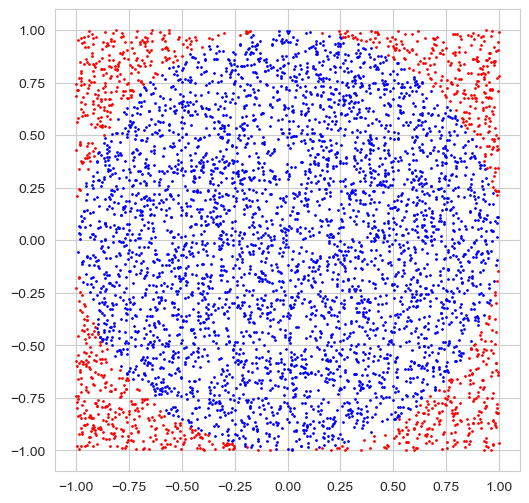

In [26]:
plt.figure(figsize=(6,6))
subset = 5000
plt.scatter(x[:subset][inside[:subset]], y[:subset][inside[:subset]],
            color='blue', s=1, label='Inside')
plt.scatter(x[:subset][~inside[:subset]], y[:subset][~inside[:subset]],
            color='red', s=1, label='Outside')

C:\Users\1124student\AppData\Local\Temp\ipykernel_4568\4179633.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


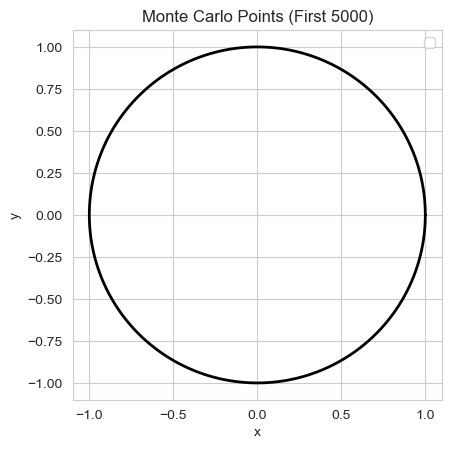

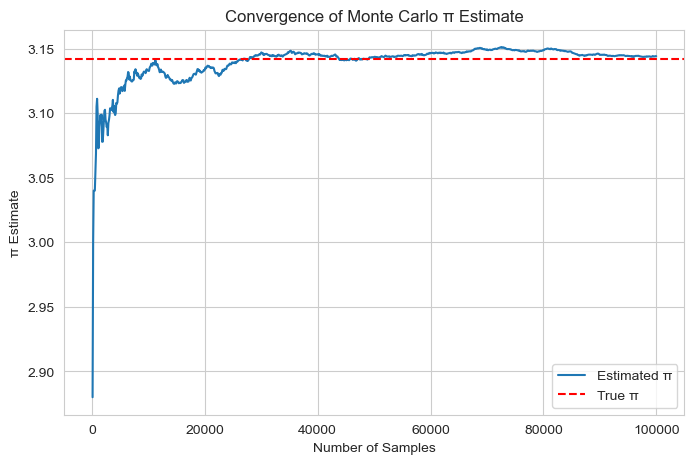

Estimate first stabilizes within ±0.01 at around n = 6400


In [27]:
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2)

plt.title("Monte Carlo Points (First 5000)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

# 5. Convergence plot
step = 100
running_estimates = []
sample_sizes = []

for i in range(step, n+1, step):
    pi_i = 4 * np.sum(inside[:i]) / i
    running_estimates.append(pi_i)
    sample_sizes.append(i)

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, running_estimates, label="Estimated π")
plt.axhline(y=pi_true, color='red', linestyle='--', label="True π")

plt.title("Convergence of Monte Carlo π Estimate")
plt.xlabel("Number of Samples")
plt.ylabel("π Estimate")
plt.legend()
plt.show()

# 6. Stability check (within ±0.01)
tolerance = 0.01
stable_n = None

for i, est in zip(sample_sizes, running_estimates):
    if abs(est - pi_true) <= tolerance:
        stable_n = i
        break

print(f"Estimate first stabilizes within ±0.01 at around n = {stable_n}")

Task 2

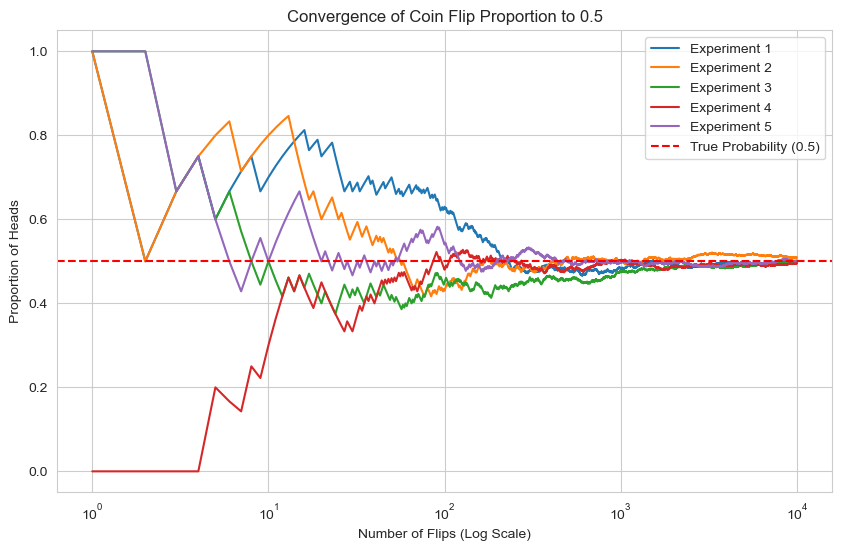

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Simulyasiya funksiyası
def coin_flip_simulation(num_flips):
    flips = np.random.choice([0, 1], size=num_flips)  # 0 - yazı, 1 - baş
    running_proportion = np.cumsum(flips) / np.arange(1, num_flips+1)  # Faiz hesablama
    return running_proportion

# Parametrlər
num_flips = 10000
experiments = 5

# Qrafik yaratmaq
plt.figure(figsize=(10, 6))

# 5 dəfə təkrarlayırıq
for _ in range(experiments):
    running_proportion = coin_flip_simulation(num_flips)
    plt.plot(np.arange(1, num_flips+1), running_proportion, label=f"Experiment {_+1}")

# Həqiqi pi = 0.5 xətti
plt.axhline(0.5, color='red', linestyle='--', label="True Probability (0.5)")

# Qrafikin parametrləri
plt.xscale('log')  # X oxunu logaritmik ölçü ilə göstər
plt.title("Convergence of Coin Flip Proportion to 0.5")
plt.xlabel("Number of Flips (Log Scale)")
plt.ylabel("Proportion of Heads")
plt.legend()

# Qrafiki göstər
plt.show()

Task 3

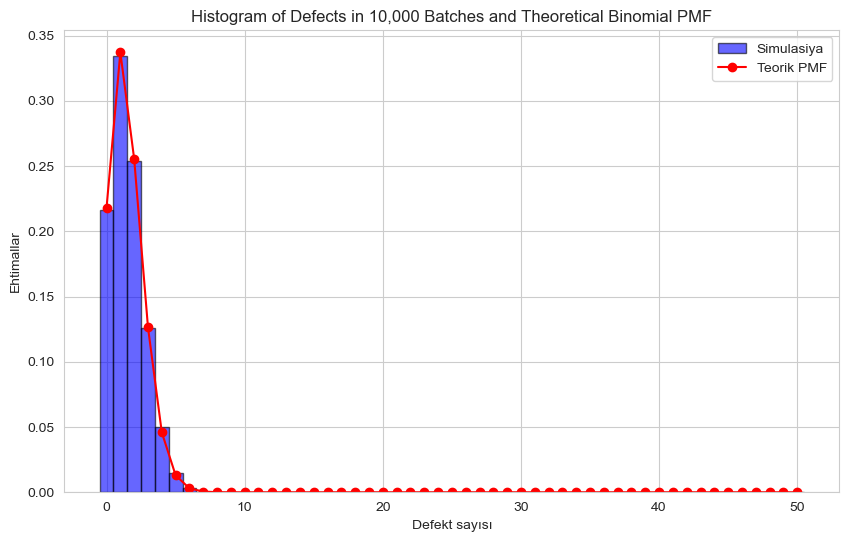

P(0 defekt) = 0.2167
P(3 və ya daha çox defekt) = 0.1948
Gözlənilən defekt sayı = 1.5192

Teorik Ehtimallar:
P(0 defekt) (Teorik) = 0.21806537534740766
P(3 və ya daha çox defekt) (Teorik) = 0.18920192463027863
Gözlənilən defekt sayı (Teorik) = 1.5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parametrlər
n = 50  # Widget sayı
p = 0.03  # Defekt ehtimalı
batches = 10000  # Batcher sayı

# 10,000 partiya simulyasiyası
defects = np.random.binomial(n, p, batches)

# Histogram yaratmaq
plt.figure(figsize=(10, 6))

# Simulyasiya nəticələrinin histogramı
plt.hist(defects, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.6, color='b', label="Simulasiya", edgecolor="black")

# Binomial paylanmanın nəzəri PMF-ni əlavə et
x = np.arange(0, n+1)
pmf_theoretical = binom.pmf(x, n, p)
plt.plot(x, pmf_theoretical, 'ro-', label="Teorik PMF")

# Qrafikin parametrləri
plt.title("Histogram of Defects in 10,000 Batches and Theoretical Binomial PMF")
plt.xlabel("Defekt sayısı")
plt.ylabel("Ehtimallar")
plt.legend()

# Qrafiki göstər
plt.show()

# Ehtimalları hesablamaq
P_0_defects = np.mean(defects == 0)
P_3_or_more_defects = np.mean(defects >= 3)
expected_defects = np.mean(defects)

# Nəticələri yazdırmaq
print(f"P(0 defekt) = {P_0_defects}")
print(f"P(3 və ya daha çox defekt) = {P_3_or_more_defects}")
print(f"Gözlənilən defekt sayı = {expected_defects}")

# Teorik qiymətlər ilə müqayisə
P_0_defects_theoretical = binom.pmf(0, n, p)
P_3_or_more_defects_theoretical = 1 - binom.cdf(2, n, p)
expected_defects_theoretical = n * p

print("\nTeorik Ehtimallar:")
print(f"P(0 defekt) (Teorik) = {P_0_defects_theoretical}")
print(f"P(3 və ya daha çox defekt) (Teorik) = {P_3_or_more_defects_theoretical}")
print(f"Gözlənilən defekt sayı (Teorik) = {expected_defects_theoretical}")